In [1]:
!pip install openmeteo-requests requests-cache retry-requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry

print("All imports successful!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.7/817.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.3 MB/s eta 0:00:00
All imports successful!
Pandas: 2.2.3
Numpy: 2.1.3


In [2]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup cached + retry session
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"

cities = {
	"Mumbai": (19.0760, 72.8777),
	"Kerala_Kochi": (9.9312, 76.2673),
	"Delhi": (28.6139, 77.2090),
	"Kolkata": (22.5726, 88.3639),
	"Chennai": (13.0827, 80.2707)
}

all_data = {}

for city, (lat, lon) in cities.items():
	params = {
		"latitude": lat,
		"longitude": lon,
		"start_date": "2015-06-01",
		"end_date": "2024-09-30",
		"daily": ["precipitation_sum", "temperature_2m_max", "temperature_2m_min", "relative_humidity_2m_mean", "wind_speed_10m_max"],
		"timezone": "Asia/Kolkata"
	}
	responses = openmeteo.weather_api(url, params=params)
	all_data[city] = responses[0]
	print(f"{city}: fetched, elevation {responses[0].Elevation()}m")

Mumbai: fetched, elevation 6.0m
Kerala_Kochi: fetched, elevation 6.0m
Delhi: fetched, elevation 214.0m
Kolkata: fetched, elevation 12.0m
Chennai: fetched, elevation 12.0m


In [3]:
def response_to_df(response, city_name):
	daily = response.Daily()
	dates = pd.date_range(
		start=pd.to_datetime(daily.Time(), unit="s", utc=True),
		end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
		freq=pd.Timedelta(seconds=daily.Interval()),
		inclusive="left"
	)
	df = pd.DataFrame({
		"date": dates,
		"precipitation_sum": daily.Variables(0).ValuesAsNumpy(),
		"temp_max": daily.Variables(1).ValuesAsNumpy(),
		"temp_min": daily.Variables(2).ValuesAsNumpy(),
		"humidity_mean": daily.Variables(3).ValuesAsNumpy(),
		"wind_speed_max": daily.Variables(4).ValuesAsNumpy(),
	})
	df["city"] = city_name
	return df

city_dfs = [response_to_df(resp, city) for city, resp in all_data.items()]
weather_df = pd.concat(city_dfs, ignore_index=True)
weather_df["date"] = weather_df["date"].dt.tz_convert("Asia/Kolkata").dt.date

print(weather_df.shape)
weather_df.head()

(17050, 7)


,date,precipitation_sum,temp_max,temp_min,humidity_mean,wind_speed_max,city
0,2015-06-01,0.0,32.304001,27.903999,71.510857,22.104116,Mumbai
1,2015-06-02,0.0,32.953999,28.153999,63.985077,19.228851,Mumbai
2,2015-06-03,0.0,33.354000,27.704000,65.685738,18.782204,Mumbai
3,2015-06-04,0.0,34.304001,27.454000,69.203941,22.702845,Mumbai
4,2015-06-05,2.6,34.153999,26.903999,73.185974,19.881649,Mumbai


In [4]:
weather_df.to_csv("weather_raw_5cities_2015_2024.csv", index=False)
print("Saved:", weather_df.shape)

Saved: (17050, 7)


In [5]:
# Missing check
print(weather_df.isnull().sum())

# Monsoon months only (Jun-Sep)
weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df["month"] = weather_df["date"].dt.month
monsoon_df = weather_df[weather_df["month"].isin([6,7,8,9])]

# City-wise avg monsoon rainfall
monsoon_summary = monsoon_df.groupby("city")["precipitation_sum"].agg(["mean","sum","max"])
print(monsoon_summary)

date                 0
precipitation_sum    0
temp_max             0
temp_min             0
humidity_mean        0
wind_speed_max       0
city                 0
dtype: int64
                   mean           sum         max
city                                             
Chennai        3.744590   4568.399902   37.300003
Delhi          4.890574   5966.500000  122.699989
Kerala_Kochi  13.217049  16124.799805  104.899994
Kolkata       10.907951  13307.700195  132.300003
Mumbai        17.199919  20983.900391  251.100021


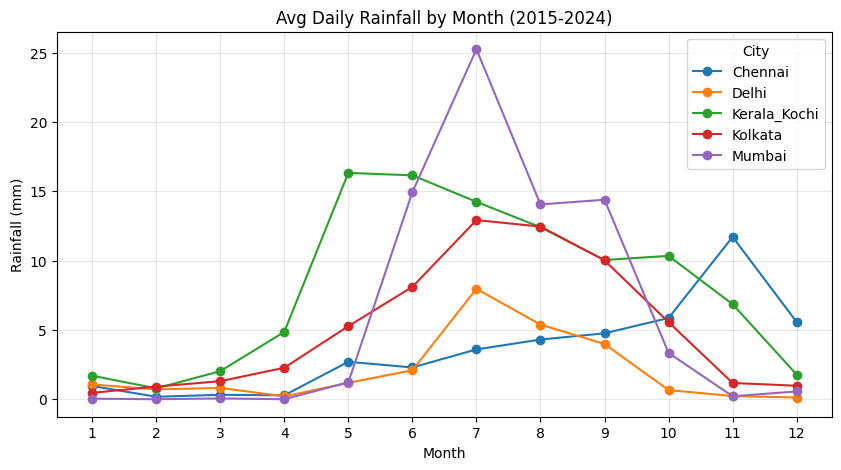

In [6]:
monthly_avg = weather_df.groupby(["city","month"])["precipitation_sum"].mean().reset_index()
pivot = monthly_avg.pivot(index="month", columns="city", values="precipitation_sum")

pivot.plot(figsize=(10,5), marker="o")
plt.title("Avg Daily Rainfall by Month (2015-2024)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.3)
plt.legend(title="City")
plt.show()

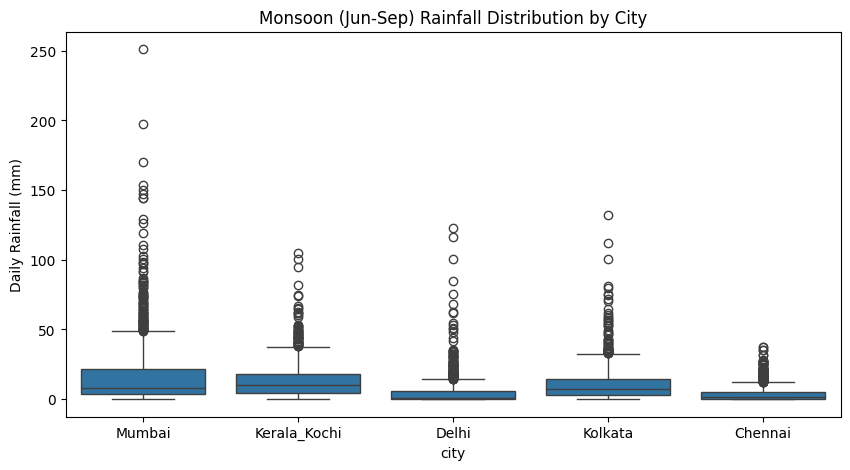

In [7]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=monsoon_df, x="city", y="precipitation_sum")
plt.title("Monsoon (Jun-Sep) Rainfall Distribution by City")
plt.ylabel("Daily Rainfall (mm)")
plt.show()

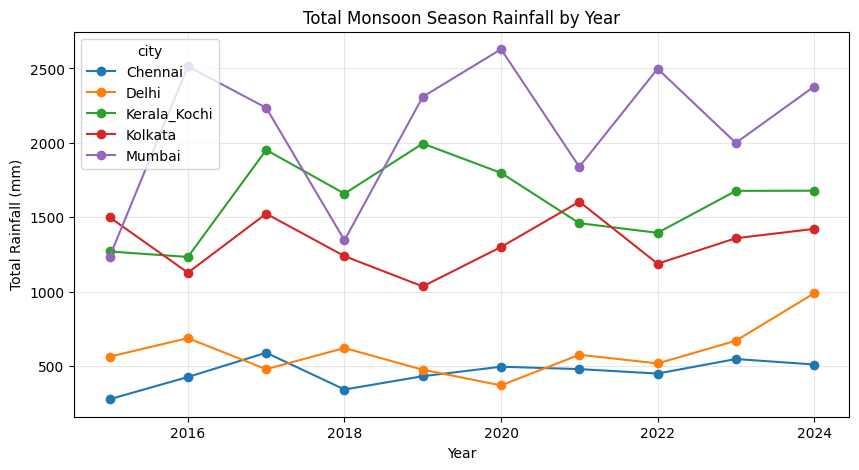

In [8]:
weather_df["year"] = weather_df["date"].dt.year
yearly_monsoon = weather_df[weather_df["month"].isin([6,7,8,9])].groupby(["city","year"])["precipitation_sum"].sum().reset_index()
pivot_year = yearly_monsoon.pivot(index="year", columns="city", values="precipitation_sum")

pivot_year.plot(figsize=(10,5), marker="o")
plt.title("Total Monsoon Season Rainfall by Year")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import time

extra_vars = ["surface_pressure_mean", "cloud_cover_mean", "cloud_cover_max"]

all_data_extra = {}

for city, (lat, lon) in cities.items():
	params = {
		"latitude": lat,
		"longitude": lon,
		"start_date": "2015-06-01",
		"end_date": "2024-09-30",
		"daily": ["precipitation_sum", "temperature_2m_max", "temperature_2m_min",
				  "relative_humidity_2m_mean", "wind_speed_10m_max"] + extra_vars,
		"timezone": "Asia/Kolkata"
	}
	try:
		responses = openmeteo.weather_api(url, params=params)
		all_data_extra[city] = responses[0]
		print(f"{city}: fetched")
	except Exception as e:
		print(f"{city}: FAILED — {e}")
	time.sleep(15)   # avoid rate limit, 4 req/min safe

Mumbai: fetched
Kerala_Kochi: fetched
Delhi: fetched
Kolkata: fetched
Chennai: fetched


In [14]:
def response_to_df_v2(response, city_name):
	daily = response.Daily()
	dates = pd.date_range(
		start=pd.to_datetime(daily.Time(), unit="s", utc=True),
		end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
		freq=pd.Timedelta(seconds=daily.Interval()),
		inclusive="left"
	)
	df = pd.DataFrame({
		"date": dates,
		"precipitation_sum": daily.Variables(0).ValuesAsNumpy(),
		"temp_max": daily.Variables(1).ValuesAsNumpy(),
		"temp_min": daily.Variables(2).ValuesAsNumpy(),
		"humidity_mean": daily.Variables(3).ValuesAsNumpy(),
		"wind_speed_max": daily.Variables(4).ValuesAsNumpy(),
		"pressure_mean": daily.Variables(5).ValuesAsNumpy(),
		"cloud_cover_mean": daily.Variables(6).ValuesAsNumpy(),
		"cloud_cover_max": daily.Variables(7).ValuesAsNumpy(),
	})
	df["city"] = city_name
	df["date"] = df["date"].dt.tz_convert("Asia/Kolkata").dt.date
	return df

city_dfs_v2 = [response_to_df_v2(resp, city) for city, resp in all_data_extra.items()]
weather_df_full = pd.concat(city_dfs_v2, ignore_index=True)

print(weather_df_full.shape)
weather_df_full.head()

(17050, 10)


,date,precipitation_sum,temp_max,temp_min,humidity_mean,wind_speed_max,pressure_mean,cloud_cover_mean,cloud_cover_max,city
0,2015-06-01,0.0,32.304001,27.903999,71.510857,22.104116,1004.807617,40.666668,68.0,Mumbai
1,2015-06-02,0.0,32.953999,28.153999,63.985077,19.228851,1006.290710,20.250000,41.0,Mumbai
2,2015-06-03,0.0,33.354000,27.704000,65.685738,18.782204,1005.600037,20.125000,62.0,Mumbai
3,2015-06-04,0.0,34.304001,27.454000,69.203941,22.702845,1005.349365,24.208334,69.0,Mumbai
4,2015-06-05,2.6,34.153999,26.903999,73.185974,19.881649,1006.278015,91.750000,100.0,Mumbai


In [15]:
weather_df_full.to_csv("weather_full_5cities_2015_2024.csv", index=False)
print("Saved:", weather_df_full.shape)

Saved: (17050, 10)


In [16]:
weather_df_full["date"] = pd.to_datetime(weather_df_full["date"])
weather_df_full = weather_df_full.sort_values(["city","date"]).reset_index(drop=True)

# Lag features (yesterday's values help predict today)
for col in ["precipitation_sum","temp_max","humidity_mean","pressure_mean"]:
	weather_df_full[f"{col}_lag1"] = weather_df_full.groupby("city")[col].shift(1)
	weather_df_full[f"{col}_lag3"] = weather_df_full.groupby("city")[col].shift(3)

# Rolling averages (7-day trend)
for col in ["precipitation_sum","humidity_mean","pressure_mean"]:
	weather_df_full[f"{col}_roll7"] = (
		weather_df_full.groupby("city")[col]
		.transform(lambda x: x.rolling(7, min_periods=1).mean())
	)

# Monsoon onset flag (first day precipitation > 2.5mm sustained 3 days, per city per year)
weather_df_full["month"] = weather_df_full["date"].dt.month
weather_df_full["year"] = weather_df_full["date"].dt.year
weather_df_full["is_monsoon_season"] = weather_df_full["month"].isin([6,7,8,9]).astype(int)

# Day of year (seasonality signal for models)
weather_df_full["day_of_year"] = weather_df_full["date"].dt.dayofyear

print(weather_df_full.shape)
weather_df_full.tail()

(17050, 25)


,date,precipitation_sum,temp_max,temp_min,humidity_mean,wind_speed_max,pressure_mean,cloud_cover_mean,cloud_cover_max,city,...,humidity_mean_lag3,pressure_mean_lag1,pressure_mean_lag3,precipitation_sum_roll7,humidity_mean_roll7,pressure_mean_roll7,month,year,is_monsoon_season,day_of_year
17045,2024-09-26,47.999996,26.549999,24.500000,94.038383,18.681883,1002.482727,100.000000,100.0,Mumbai,...,86.978416,1003.524719,1005.959290,17.499999,88.120455,1005.437744,9,2024,1,270
17046,2024-09-27,61.700005,26.799999,25.500000,90.321724,28.108831,1004.078613,99.875000,100.0,Mumbai,...,90.561409,1002.482727,1004.216797,25.571429,88.634543,1005.008780,9,2024,1,271
17047,2024-09-28,5.800000,28.049999,24.850000,86.062775,17.885334,1007.348328,97.916664,100.0,Mumbai,...,92.321869,1004.078613,1003.524719,26.128571,89.040058,1004.946193,9,2024,1,272
17048,2024-09-29,4.600000,28.650000,25.000000,87.695618,14.764389,1009.417908,57.333332,99.0,Mumbai,...,94.038383,1007.348328,1002.482727,26.471429,89.711456,1005.289769,9,2024,1,273
17049,2024-09-30,1.600000,29.700001,24.700001,87.887032,15.156384,1009.447998,29.583334,86.0,Mumbai,...,90.321724,1009.417908,1004.078613,25.885714,89.841258,1005.788156,9,2024,1,274


In [17]:
weather_df_full.to_csv("weather_features_5cities_2015_2024.csv", index=False)
print("Saved:", weather_df_full.shape)

Saved: (17050, 25)


In [18]:
from google.colab import files
files.download("weather_features_5cities_2015_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>